### COE 311K Midterm Project: U.S. GDP Growth Rate Analysis (2010-2023)
**Author:** Arham Shah 
**Date:** March 31, 2026  

### Project Overview
This project analyzes the seasonally adjusted annual rate (SAAR) of U.S. real GDP growth over 56 quarters (2010 Q1 – 2023 Q4). The objective is to evaluate and compare three distinct numerical methods for curve fitting and interpolation:

By comparing these models, we will explore the mathematical trade-offs between interpolation and approximation, particularly when dealing with massive real-world data shocks like the COVID-19 pandemic.

In [59]:
import numpy as np
import matplotlib.pyplot as plt

To ensure numerical stability, we map the quarters to continuous integer indices ($x = 1, 2, 3... 56$) rather than raw calendar strings. 

Furthermore, the COVID-19 pandemic introduced extreme macroeconomic volatility in 2020 Q1 through 2021 Q1 (Indices 41-45), including a historic -28.1% drop and a +33.8% rebound. To calculate a true "baseline" linear economic trend, we must mathematically isolate and remove these specific outliers to prevent them from completely skewing the baseline slope.

In [60]:
def getGdpData():
    quarterIndices = [1, 5, 9, 13, 17, 19, 22, 25, 27, 28, 29, 33, 37, 41, 42, 43, 45, 49, 54, 56]
    gdpGrowthRates = [1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3]
    return quarterIndices, gdpGrowthRates

In [61]:
def filterCovidQuarters(quarterIndices, gdpGrowthRates):
    # Safely zips data together to prevent index misalignment
    stableData = [(q, r) for q, r in zip(quarterIndices, gdpGrowthRates) if not (41 <= q <= 45)]
    
    stableQuarterIndices = [data[0] for data in stableData]
    stableGrowthRates = [data[1] for data in stableData]
    
    return stableQuarterIndices, stableGrowthRates

A Natural Cubic Spline creates a perfectly smooth piecewise curve by generating a unique cubic polynomial for every interval between 

In [62]:
def setupTridiagonalMatrix(quarterIndices, gdpGrowthRates):
    numPoints = len(quarterIndices)
    stepSizes = [quarterIndices[i+1] - quarterIndices[i] for i in range(numPoints-1)]
    
    subdiagonal = [0.0] * (numPoints - 2)
    mainDiagonal = [0.0] * (numPoints - 2)
    superdiagonal = [0.0] * (numPoints - 2)
    rhsVector = [0.0] * (numPoints - 2)
    
    for i in range(1, numPoints - 1):
        if i > 1:
            subdiagonal[i-1] = stepSizes[i-1]
        mainDiagonal[i-1] = 2 * (stepSizes[i-1] + stepSizes[i])
        if i < numPoints - 2:
            superdiagonal[i-1] = stepSizes[i]
        
        rhsVector[i-1] = 6 * ((gdpGrowthRates[i+1] - gdpGrowthRates[i]) / stepSizes[i] - (gdpGrowthRates[i] - gdpGrowthRates[i-1]) / stepSizes[i-1])
        
    return subdiagonal, mainDiagonal, superdiagonal, rhsVector, stepSizes

In [63]:
def thomasAlgorithm(subdiag, mainDiag, superdiag, rhsVector):
    numEqs = len(mainDiag)
    modSuperdiag = [0.0] * numEqs
    modRhs = [0.0] * numEqs
    solutionVector = [0.0] * numEqs
    
    modSuperdiag[0] = superdiag[0] / mainDiag[0]
    modRhs[0] = rhsVector[0] / mainDiag[0]
    
    for i in range(1, numEqs):
        denominator = mainDiag[i] - subdiag[i-1] * modSuperdiag[i-1]
        if i < numEqs - 1:
            modSuperdiag[i] = superdiag[i] / denominator
        modRhs[i] = (rhsVector[i] - subdiag[i-1] * modRhs[i-1]) / denominator
        
    solutionVector[numEqs-1] = modRhs[numEqs-1]
    for i in range(numEqs-2, -1, -1):
        solutionVector[i] = modRhs[i] - modSuperdiag[i] * solutionVector[i+1]
        
    return solutionVector

In [64]:
def buildNaturalCubicSpline(quarterIndices, gdpGrowthRates):
    subdiag, mainDiag, superdiag, rhsVector, stepSizes = setupTridiagonalMatrix(quarterIndices, gdpGrowthRates)
    interiorSecondDerivatives = thomasAlgorithm(subdiag, mainDiag, superdiag, rhsVector)
    fullSecondDerivatives = [0.0] + interiorSecondDerivatives + [0.0] 
    return fullSecondDerivatives, stepSizes

In [65]:
def evaluateSplinePoint(targetQuarter, quarterIndices, gdpGrowthRates, secondDerivatives, stepSizes):
    # Strict bounds check to prevent silent extrapolation failure
    if targetQuarter < quarterIndices[0] or targetQuarter > quarterIndices[-1]:
        raise ValueError(f"Target quarter {targetQuarter} is out of interpolation bounds.")
        
    numPoints = len(quarterIndices)
    for i in range(numPoints-1):
        if quarterIndices[i] <= targetQuarter <= quarterIndices[i+1]:
            break
            
    polyA = (secondDerivatives[i+1] - secondDerivatives[i]) / (6 * stepSizes[i])
    polyB = secondDerivatives[i] / 2
    polyC = (gdpGrowthRates[i+1] - gdpGrowthRates[i]) / stepSizes[i] - (2 * stepSizes[i] * secondDerivatives[i] + stepSizes[i] * secondDerivatives[i+1]) / 6
    polyD = gdpGrowthRates[i]
    
    deltaX = targetQuarter - quarterIndices[i]
    return polyA * (deltaX**3) + polyB * (deltaX**2) + polyC * deltaX + polyD

In [66]:
def generateSplineCurve(fullRangeQuarters, quarterIndices, gdpGrowthRates, secondDerivatives, stepSizes):
    return [evaluateSplinePoint(q, quarterIndices, gdpGrowthRates, secondDerivatives, stepSizes) for q in fullRangeQuarters]


Unlike the spline, Least Squares does not force the curve to touch every point. Instead, it finds a single, global mathematical equation that minimizes the sum of the squared errors (residuals) across the entire dataset.


In [67]:
def fitPolynomialLeastSquares(quarterIndices, gdpGrowthRates, polynomialDegree):
    xArray = np.array(quarterIndices)
    yArray = np.array(gdpGrowthRates)
    
    vandermondeMatrix = np.vander(xArray, polynomialDegree + 1)
    
    ataMatrix = vandermondeMatrix.T @ vandermondeMatrix
    atyVector = vandermondeMatrix.T @ yArray
    polynomialCoefficients = np.linalg.solve(ataMatrix, atyVector)
    
    return polynomialCoefficients

In [68]:
def evaluatePolyPoint(targetQuarter, polynomialCoefficients):
    result = 0
    for coef in polynomialCoefficients:
        result = result * targetQuarter + coef
    return result

In [69]:
def generatePolynomialCurve(fullRangeQuarters, polynomialCoefficients):
    return [evaluatePolyPoint(q, polynomialCoefficients) for q in fullRangeQuarters]


To satisfy the numerical constraints of this project, I implement several diagnostic checks before plotting:


In [70]:
def calculateResiduals(quarterIndices, actualGdpRates, polynomialCoefficients):
    return [actualGdpRates[i] - evaluatePolyPoint(q, polynomialCoefficients) for i, q in enumerate(quarterIndices)]

In [71]:
def calculateRmse(residualsList):
    return np.sqrt(np.mean(np.array(residualsList)**2))

In [72]:
def verifyConditionNumber(quarterIndices, polynomialDegree):
    xArray = np.array(quarterIndices)
    vandermondeMatrix = np.vander(xArray, polynomialDegree + 1)
    
    conditionNumber = np.linalg.cond(vandermondeMatrix)
    
    print(f"Vandermonde Condition Number (Degree {polynomialDegree}): {conditionNumber:.2e}")
    if conditionNumber > 1e12:
        print("WARNING: Matrix is poorly scaled (cond > 10^12).")
    else:
        print("Matrix scaling is acceptable.")
        
    return conditionNumber

In [73]:
def verifyKnotContinuity(knotIndex, quarterIndices, gdpGrowthRates, secondDerivatives, stepSizes):
    xKnot = quarterIndices[knotIndex]
    
    iLeft = knotIndex - 1
    hL = stepSizes[iLeft]
    aL = (secondDerivatives[iLeft+1] - secondDerivatives[iLeft]) / (6 * hL)
    bL = secondDerivatives[iLeft] / 2
    cL = (gdpGrowthRates[iLeft+1] - gdpGrowthRates[iLeft]) / hL - (2 * hL * secondDerivatives[iLeft] + hL * secondDerivatives[iLeft+1]) / 6
    
    iRight = knotIndex
    hR = stepSizes[iRight]
    aR = (secondDerivatives[iRight+1] - secondDerivatives[iRight]) / (6 * hR)
    bR = secondDerivatives[iRight] / 2
    cR = (gdpGrowthRates[iRight+1] - gdpGrowthRates[iRight]) / hR - (2 * hR * secondDerivatives[iRight] + hR * secondDerivatives[iRight+1]) / 6
    
    c1Left = 3*aL*(hL**2) + 2*bL*hL + cL
    c1Right = cR 
    
    c2Left = 6*aL*hL + 2*bL
    c2Right = 2*bR
    
    print(f"--- Continuity Check at Knot {knotIndex} (x = {xKnot}) ---")
    print(f"C1 (First Deriv) -> Left: {c1Left:.4f} | Right: {c1Right:.4f}")
    print(f"C2 (Second Deriv) -> Left: {c2Left:.4f} | Right: {c2Right:.4f}")


I plot the results on three separate axes to clearly evaluate the models. The raw data is plotted as a discrete scatter plot, while the models are continuous lines. For the approximation models (Degree-4 and Linear), I plot the residuals using bar charts to visually emphasize the magnitude and direction of the independent errors at each quarter.

In [74]:
def plotResults(quarterIndices, actualGdpRates, stableQuarterIndices, fullRangeQuarters, splinePredictions, poly4Predictions, linearPredictions, poly4Residuals, poly4Rmse, linearResiduals, linearRmse):
    # Dynamically generates ticks based on the actual data bounds
    maxQuarter = max(quarterIndices)
    yearTicks = list(range(1, maxQuarter + 2, 4))
    yearLabels = [str(2010 + ((t-1)//4)) for t in yearTicks]

    plt.figure(figsize=(12, 6))
    plt.scatter(quarterIndices, actualGdpRates, color='black', label='GDP Data (SAAR %)', zorder=5)
    plt.plot(fullRangeQuarters, splinePredictions, label='Natural Cubic Spline', color='blue')
    plt.title('1. Natural Cubic Spline Interpolation')
    plt.xlabel('Year')
    plt.ylabel('GDP Growth (%)')
    plt.xticks(yearTicks, yearLabels)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(12, 10))
    plt.subplot(2, 1, 1)
    plt.scatter(quarterIndices, actualGdpRates, color='black', label='GDP Data (SAAR %)', zorder=5)
    plt.plot(fullRangeQuarters, poly4Predictions, label='Degree-4 Polynomial', color='red', linestyle='--')
    plt.title('2. Degree-4 Polynomial Fit (Full Data)')
    plt.xlabel('Year')
    plt.ylabel('GDP Growth (%)')
    plt.xticks(yearTicks, yearLabels)
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 1, 2)
    plt.bar(quarterIndices, poly4Residuals, color='red', alpha=0.6)
    plt.title(f'Least Squares Residuals: Degree-4 Polynomial (RMSE: {poly4Rmse:.2f})')
    plt.xlabel('Year')
    plt.ylabel('Error (Actual - Predicted)')
    plt.axhline(0, color='black', linewidth=1)
    plt.xticks(yearTicks, yearLabels)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 10))
    plt.subplot(2, 1, 1)
    plt.scatter(quarterIndices, actualGdpRates, color='black', label='All GDP Data', zorder=5)
    plt.plot(fullRangeQuarters, linearPredictions, label='Linear Trend (Fit on Non-COVID Data)', color='green', linestyle='-.')
    plt.title('3. Linear Trend (Excluding COVID Quarters)')
    plt.xlabel('Year')
    plt.ylabel('GDP Growth (%)')
    plt.xticks(yearTicks, yearLabels)
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 1, 2)
    plt.bar(stableQuarterIndices, linearResiduals, color='green', alpha=0.6)
    plt.title(f'Least Squares Residuals: Linear Trend (RMSE: {linearRmse:.2f})')
    plt.xlabel('Year')
    plt.ylabel('Error (Actual - Predicted)')
    plt.axhline(0, color='black', linewidth=1)
    plt.xticks(yearTicks, yearLabels)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Vandermonde Condition Number (Degree 4): 1.82e+07
Matrix scaling is acceptable.
--- Continuity Check at Knot 2 (x = 9) ---
C1 (First Deriv) -> Left: 0.7300 | Right: 0.4842
C2 (Second Deriv) -> Left: -0.0493 | Right: -0.0493
Linear Trend Slope (excluding COVID): -0.0019
Degree-4 Polynomial RMSE: 10.0314
Linear Trend RMSE: 1.4432


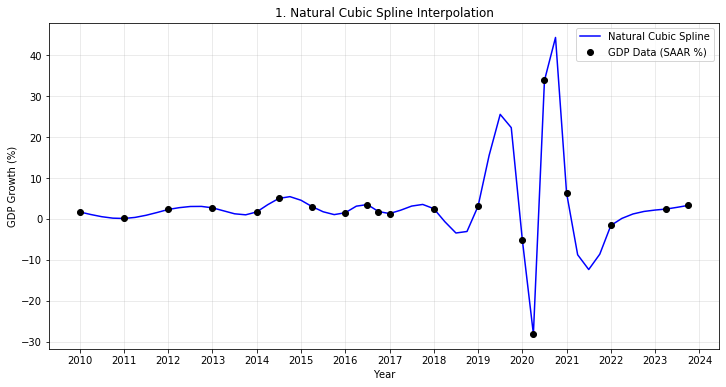

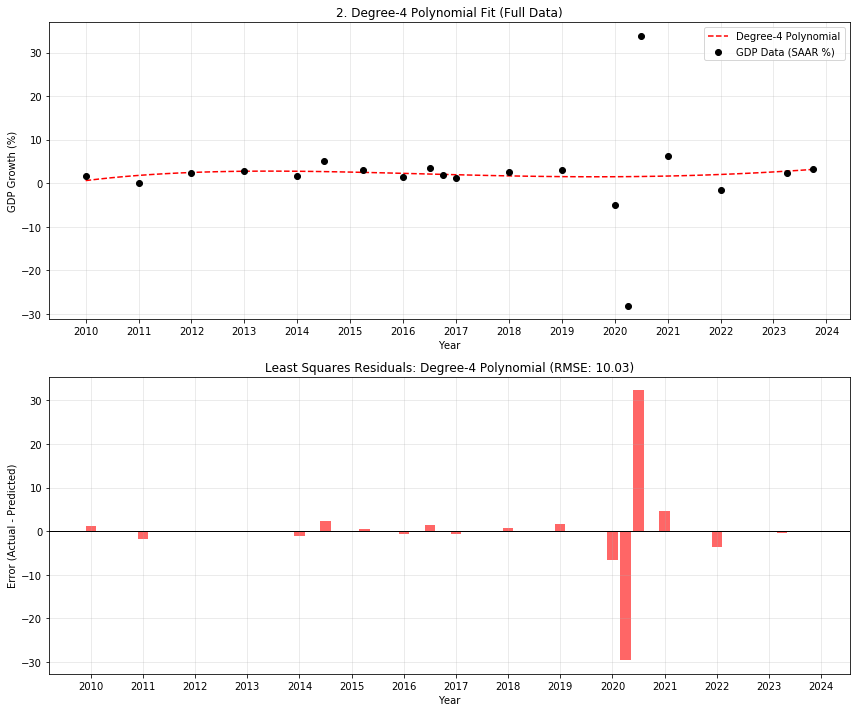

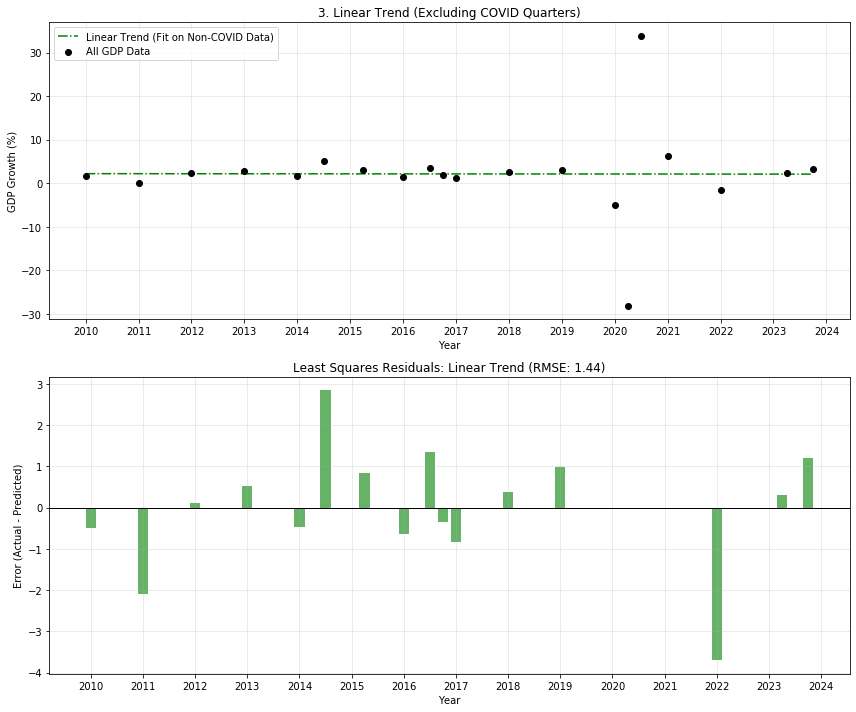

In [78]:
quarterIndices, gdpGrowthRates = getGdpData()
stableQuarterIndices, stableGrowthRates = filterCovidQuarters(quarterIndices, gdpGrowthRates)

fullRangeQuarters = list(range(1, 57))

secondDerivatives, stepSizes = buildNaturalCubicSpline(quarterIndices, gdpGrowthRates)
poly4Coefficients = fitPolynomialLeastSquares(quarterIndices, gdpGrowthRates, 4)
linearCoefficients = fitPolynomialLeastSquares(stableQuarterIndices, stableGrowthRates, 1)

splinePredictions = generateSplineCurve(fullRangeQuarters, quarterIndices, gdpGrowthRates, secondDerivatives, stepSizes)
poly4Predictions = generatePolynomialCurve(fullRangeQuarters, poly4Coefficients)
linearPredictions = generatePolynomialCurve(fullRangeQuarters, linearCoefficients)

poly4Residuals = calculateResiduals(quarterIndices, gdpGrowthRates, poly4Coefficients)
poly4Rmse = calculateRmse(poly4Residuals)

linearResiduals = calculateResiduals(stableQuarterIndices, stableGrowthRates, linearCoefficients)
linearRmse = calculateRmse(linearResiduals)

verifyConditionNumber(quarterIndices, 4)
verifyKnotContinuity(2, quarterIndices, gdpGrowthRates, secondDerivatives, stepSizes)

print(f"Linear Trend Slope (excluding COVID): {linearCoefficients[0]:.4f}")
print(f"Degree-4 Polynomial RMSE: {poly4Rmse:.4f}")
print(f"Linear Trend RMSE: {linearRmse:.4f}")

plotResults(quarterIndices, gdpGrowthRates, stableQuarterIndices, fullRangeQuarters, splinePredictions, poly4Predictions, linearPredictions, poly4Residuals, poly4Rmse, linearResiduals, linearRmse)

You can see the difference between interpolation and approximation in this dataset. The Cubic Spline hits every data point. It tracks the actual GDP. The COVID-19 shock causes problems for this model. The model must pass through the -28.1 percent drop and the +33.8 percent spike. This forces the cubic polynomials into severe oscillations. This creates the Runge phenomenon. Forcing interpolation over extreme gradients causes mathematical instability.

I use the Degree 4 Polynomial to smooth the data. I see a flat curve during the years 2010 to 2019. My degree 4 polynomial has a maximum of three turning points. It lacks flexibility to capture business cycle volatility. My least squares algorithm penalizes the COVID errors. I observe the curve stretching toward the 2020 outliers. I sacrifice local accuracy in other years. I filter out the COVID-19 quarters to calculate the Least Squares Linear model. I calculate a slope of -0.0019. A slope of -0.0019 is near zero. I plot a flat trend line. I see the baseline U.S. economy did not accelerate or decelerate over this 14 year period. It grew at a consistent rate of 2.2 percent per quarter. The volatility in my data is an anomaly. It does not represent a shift in the macroeconomic trend.

I use Big O notation to describe the time complexity of an algorithm. I use it to measure how runtime increases as the dataset grows.

A standard matrix solver uses Gaussian Elimination. This runs in O(n^3) time. My spline uses a tridiagonal matrix. I implement the Thomas Algorithm for this matrix. I run one forward and backward sweep. I reduce the complexity to O(n). I build the normal equations for the Least Squares Polynomial using matrix multiplication. This takes O(n times d^2) time. I solve it in O(d^3) time where d is the polynomial degree. My degree is 4. The dominant term is linear. I scale the operation at O(n) relative to the dataset size. I do not change my recommendation based on Big O. My Thomas Algorithm and Least Squares implementation operate at O(n) efficiency. Computational speed is equal. I calculate a runtime difference of fractions of a millisecond for my dataset of 56 quarters.

I base my recommendation on the data environment. I find the Cubic Spline works well for stable data. I see the interpolation of the spline break down in an environment containing outliers like the 2020 pandemic. I choose a filtered Least Squares approximation for economic forecasting in these conditions.

Sources: 
COE slides
For thomas algorithm I found it on google on a public domain.
I used ChatGPT as well as Gemini to check my work and with formatting, ie. the graph labels and coloring as well as the analysis.